In [1]:
# Download NLTK resources
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

# Core libraries
import pandas as pd
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [9]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [11]:
df_reviews = pd.read_csv(r"C:\laragon\www\web\lokalkita\data\cleaned_review.csv")
print("✅ Data loaded:", df_reviews.shape)
df_reviews.head(3)

✅ Data loaded: (15452, 6)


,Title,Username,Review,clean_review,translated_review,final_review
0,A’moss,AIN NADIAH,We have our Anniversary Trip here for 2D 1N.Th...,we have our anniversary trip here for d nthe s...,we have our anniversary trip here for d nthe s...,we have our anniversary trip here for d nthe s...
1,A’moss,Nur Suhaira,"An Unforgettable Escape - Homely, Breathtaking...",an unforgettable escape homely breathtaking an...,an unforgettable escape homely breathtaking an...,an unforgettable escape homely breathtaking an...
2,A’moss,Atiq Safian,If you’re looking for a peaceful escape to rel...,if you’re looking for a peaceful escape to rel...,if you’re looking for a peaceful escape to rel...,if you’re looking for a peaceful escape to rel...


In [13]:
sia = SentimentIntensityAnalyzer()

df_reviews['compound'] = df_reviews['final_review'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

df_reviews['sentiment'] = df_reviews['compound'].apply(
    lambda c: 'Positive' if c > 0.05 else ('Negative' if c < -0.05 else 'Neutral')
)

print("✅ Sentiment analysis done!")
df_reviews[['Title', 'Username', 'final_review', 'compound', 'sentiment']].head(10)

✅ Sentiment analysis done!


,Title,Username,final_review,compound,sentiment
0,A’moss,AIN NADIAH,we have our anniversary trip here for d nthe s...,0.5859,Positive
1,A’moss,Nur Suhaira,an unforgettable escape homely breathtaking an...,0.9402,Positive
2,A’moss,Atiq Safian,if you’re looking for a peaceful escape to rel...,0.9403,Positive
3,A’moss,Scott Tian,have a lovely stayed on on my birthday the mom...,0.9014,Positive
4,A’moss,Alfie Solomons,i’ve finally made my way to this elusive glamp...,-0.4754,Negative
5,A’moss,Alina Liu,this is place is magical by magical i don’t ju...,0.0000,Neutral
6,A’moss,Coffee,during my onenight stay in this place i had th...,0.9719,Positive
7,A’moss,Piraveena Sukumaran,the place is quite nice and very instagramable...,0.8361,Positive
8,A’moss,Elli LIH,a great place for glamping lovers the accommod...,0.9779,Positive
9,A’moss,Boon Ho Chew,overall experience here is very chill and very...,0.0000,Neutral


In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import string

stop_words = set(stopwords.words('english'))
custom_stopwords = {'im', 'ive', 'us', 'one', 'two', 'get', 'go', 'also', 'place'}
stop_words.update(custom_stopwords)

def extract_adjectives(text):
    if not isinstance(text, str):
        return ""
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tagged = pos_tag(tokens)
    adjectives = [word for word, pos in tagged if pos in ['JJ', 'JJR', 'JJS']]
    return " ".join(adjectives)

df_reviews['adjectives_only'] = df_reviews['final_review'].apply(extract_adjectives)
print("✅ Adjectives extracted!")
df_reviews[['final_review', 'adjectives_only']].head(10)

✅ Adjectives extracted!


,final_review,adjectives_only
0,we have our anniversary trip here for d nthe s...,anniversary amazing
1,an unforgettable escape homely breathtaking an...,unforgettable restful​our farmstay perfect spe...
2,if you’re looking for a peaceful escape to rel...,peaceful nature calm quiet
3,have a lovely stayed on on my birthday the mom...,birthday exceptional top peaceful
4,i’ve finally made my way to this elusive glamp...,elusive
5,this is place is magical by magical i don’t ju...,magical magical possible
6,during my onenight stay in this place i had th...,onenight beautiful natural cool
7,the place is quite nice and very instagramable...,nice instagramable back nature fine
8,a great place for glamping lovers the accommod...,great unique simple suitable fresh clean comfo...
9,overall experience here is very chill and very...,overall suitable quiet come due main


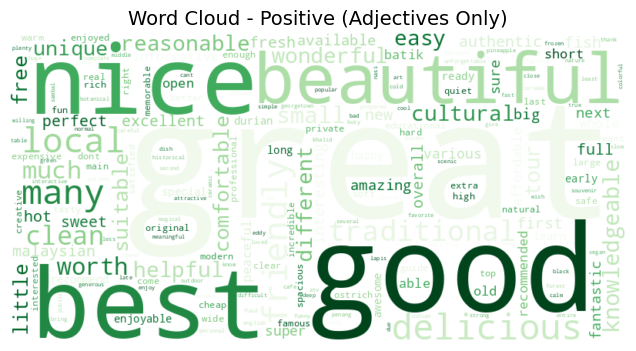

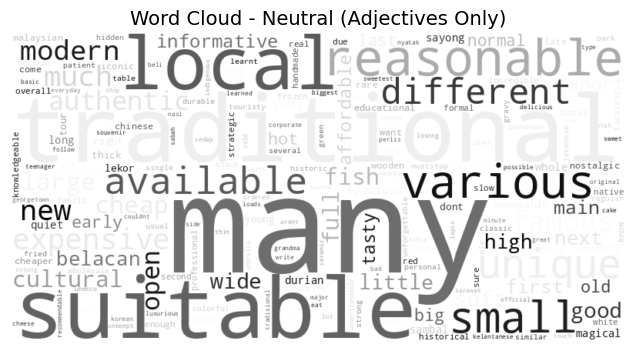

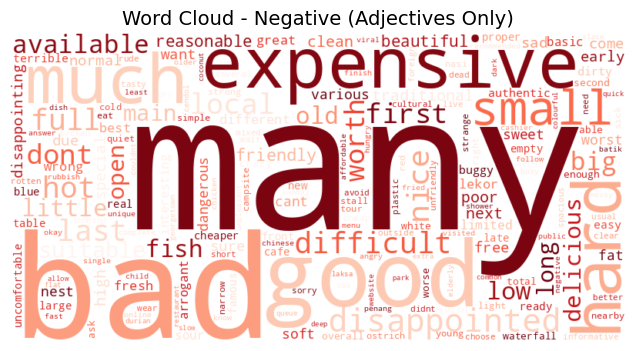

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(sentiment_label, color):
    text = " ".join(df_reviews[df_reviews['sentiment'] == sentiment_label]['adjectives_only'].astype(str))
    wc = WordCloud(width=800, height=400, background_color="white", colormap=color, collocations=False).generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud - {sentiment_label} (Adjectives Only)", fontsize=14)
    plt.show()

generate_wordcloud("Positive", "Greens")
generate_wordcloud("Neutral", "Greys")
generate_wordcloud("Negative", "Reds")

In [19]:
from collections import Counter

def top_adjectives(sentiment_label, n=15):
    text = " ".join(df_reviews[df_reviews['sentiment'] == sentiment_label]['adjectives_only'].astype(str))
    common = Counter(text.split()).most_common(n)
    return pd.DataFrame(common, columns=['Adjective', 'Count'])

print("🔹 Top Positive Adjectives")
display(top_adjectives("Positive"))

print("🔹 Top Neutral Adjectives")
display(top_adjectives("Neutral"))

print("🔹 Top Negative Adjectives")
display(top_adjectives("Negative"))

🔹 Top Positive Adjectives


,Adjective,Count
0,great,2185
1,good,2157
2,best,1343
3,nice,1274
4,beautiful,1083
5,delicious,1040
6,many,1009
7,friendly,990
8,local,981
9,traditional,628


🔹 Top Neutral Adjectives


,Adjective,Count
0,many,112
1,traditional,73
2,suitable,63
3,local,48
4,reasonable,47
5,various,40
6,small,35
7,unique,30
8,available,26
9,different,23


🔹 Top Negative Adjectives


,Adjective,Count
0,many,91
1,bad,71
2,good,64
3,expensive,35
4,much,33
5,hard,32
6,small,31
7,disappointed,28
8,nice,26
9,last,24


In [21]:
# Select useful columns for export
export_cols = [
    'Title',
    'Username',
    'final_review',
    'compound',
    'sentiment',
    'adjectives_only'
]

# Save to CSV
output_path = r"C:\laragon\www\web\lokalkita\data\sentiment_review_final.csv"
df_reviews[export_cols].to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ File saved successfully at: {output_path}")

✅ File saved successfully at: C:\laragon\www\web\lokalkita\data\sentiment_review_final.csv
